# Part 1 — Threat Detection Model
### LLM-Assisted Cyber Threat Intelligence for 5G O-RAN Security

This notebook covers **Part 1** of the exercise:
1. Load and inspect the NetsLab-5GORAN-IDD dataset
2. Exploratory data analysis (class distribution, feature summary)
3. Preprocessing (missing values, categorical encoding, class imbalance)
4. Train a multi-class classifier (XGBoost, with a Random Forest fallback)
5. Evaluate: accuracy, precision/recall, macro F1, per-class F1, confusion matrix
6. Identify commonly-confused attack pairs
7. Export per-test-event predictions + confidence + alternatives → feeds **Part 2** (CTI alert generation)

**Dataset:** [NetsLab-5GORAN-IDD on Kaggle](https://www.kaggle.com/datasets/netslabdemo/netslab-5g-oran-idd)
(DOI: 10.34740/kaggle/ds/7416931) — real-world traffic from a physical 5G O-RAN testbed at UCD,
simulating DoS/DDoS-family attacks against the O-Cloud Edge Server alongside benign traffic.

> **Before running:** download the dataset via the Kaggle API (see README) and place the extracted
> CSV file(s) in `data/raw/`. This notebook auto-discovers CSV files in that folder rather than
> hardcoding a filename, since the archive layout isn't confirmed until you unzip it locally.


In [21]:
import os
import json
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Configuration

Set these once you've inspected the real files (the discovery cell below will help).


In [22]:
RAW_DATA_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Confirmed against the real NetsLab-5GORAN-IDD Network_Dataset.csv (1,723,817 rows) ---
LABEL_COL = "attack_category"   # values: benign, dos, ddos, web, probe, bruteforce

# Identifier/metadata columns -- excluded from model features, kept aside for the CTI alert
ID_LIKE_COLS = [
    "uid", "src_ip", "dst_ip", "id", "flow_id", "timestamp", "ts", "time"
]

# CRITICAL: these columns directly encode (or near-perfectly correlate with) the label.
# attack_type is a finer-grained version of attack_category; traffic_type is a binary
# benign/attack flag derived straight from the label. Leaving either in the feature set
# would let the model "cheat" by reading the answer instead of learning from network
# behaviour -- classic label leakage. They are kept in `df` (useful context for the CTI
# alert / report) but explicitly dropped before training.
LEAKAGE_COLS = ["attack_type", "traffic_type"]

MIN_SAMPLES_PER_CLASS = 50       # drop ultra-rare classes rather than let them break stratified split
TOP_K_ALTERNATIVES = 3           # how many alternative predictions to keep per event
TEST_SIZE = 0.2


## 2. Load and discover schema

This loads every CSV under `data/raw/` and concatenates them. If the real dataset ships as
separate benign/attack files without a `label` column, this cell also tags rows using the
filename (edit the `infer_label_from_filename` function to match the actual filenames you get
from Kaggle).


In [23]:
def infer_label_from_filename(filename: str) -> str | None:
    """Best-effort label inference from filename, used only if no label column exists.
    Edit the keyword map below once you see the real filenames."""
    name = filename.lower()
    keyword_map = {
        "benign": "Benign", "normal": "Benign",
        "syn": "SYN_Flood", "synflood": "SYN_Flood",
        "udp": "UDP_Flood", "udpflood": "UDP_Flood",
        "icmp": "ICMP_Flood",
        "tcp": "TCP_Flood",
        "scan": "Port_Scan", "probe": "Port_Scan",
        "ddos": "DDoS",
        "dos": "DoS",
    }
    for kw, label in keyword_map.items():
        if kw in name:
            return label
    return None

csv_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "**", "*.csv"), recursive=True))
print(f"Found {len(csv_files)} CSV file(s):")
for f in csv_files:
    print(" ", f)

frames = []
for f in csv_files:
    d = pd.read_csv(f)
    if LABEL_COL not in d.columns:
        inferred = infer_label_from_filename(os.path.basename(f))
        if inferred is None:
            print(f"  WARNING: no label column and no inferable label for {f} -- skipping")
            continue
        d[LABEL_COL] = inferred
    frames.append(d)

assert frames, "No usable CSV files found in data/raw -- download the dataset first (see README)."
df = pd.concat(frames, ignore_index=True)
print("\nCombined shape:", df.shape)
df.head()


Found 1 CSV file(s):
  ../data/raw\Network_Dataset.csv

Combined shape: (1723817, 26)


,uid,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,dst_ip_bytes,ip_proto,http_trans_depth,attack_category,attack_type,files_total_bytes,is_GET_mthd,http_status_error,is_file_transfered,traffic_type
0,CgvPTm2yEMy1O7Jl9k,192.168.0.1,18728,192.168.0.10,80,tcp,-,0.000041,0.0,0.0,...,40,6,0,ddos,tcp_ack,0.0,0,0,0,1
1,CAOgXB1yv9VtvISnDc,172.16.0.3,29039,192.168.0.10,80,tcp,-,0.000746,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1
2,CXyf8S2WNJVYWlDI15,172.31.0.134,7552,192.168.0.10,80,tcp,-,0.000086,0.0,0.0,...,88,6,0,ddos,syn,0.0,0,0,0,1
3,CXjeD72LNi8Cn2EXZ5,172.16.0.4,59569,52.207.202.187,443,tcp,-,594.651675,73426.0,14841.0,...,55360,6,0,ddos,icmp,0.0,0,0,0,1
4,CgGkxuR9gLRepT5j2,172.16.0.3,42502,192.168.0.10,80,tcp,-,0.000290,0.0,0.0,...,80,6,0,ddos,tcp_ack,0.0,0,0,0,1


## 3. Exploratory Data Analysis

Class distribution, feature types, and missingness — all required by the exercise brief.


In [24]:
print("Columns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum()[df.isnull().sum() > 0])


Columns: ['uid', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'attack_category', 'attack_type', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered', 'traffic_type']

Dtypes:
 uid                       str
src_ip                    str
src_port                int64
dst_ip                    str
dst_port                int64
proto                     str
service                   str
duration              float64
src_bytes             float64
dst_bytes             float64
conn_state                str
missed_bytes            int64
history                   str
src_pkts                int64
src_ip_bytes            int64
dst_pkts                int64
dst_ip_bytes            int64
ip_proto                int64
http_trans_depth        int64
attack_category           str
attack_type  

attack_category
dos           632507
ddos          420282
web           288304
probe         183293
benign        170865
bruteforce     28566
Name: count, dtype: int64


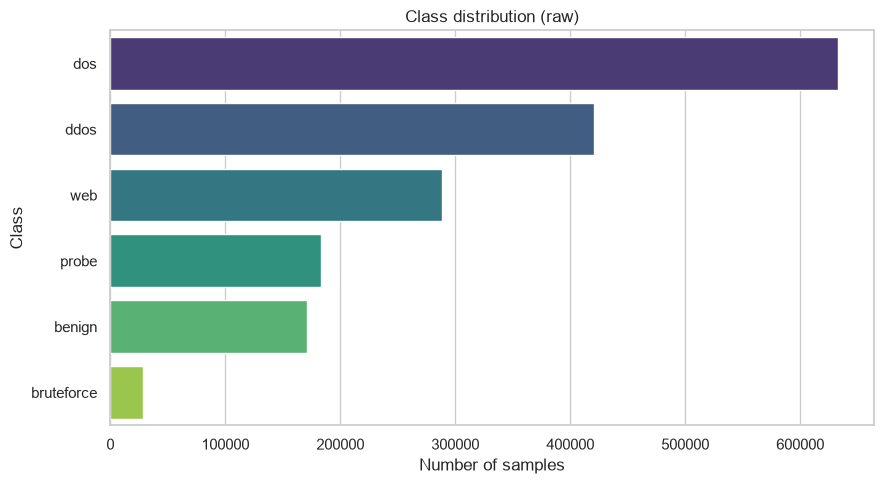

In [25]:
class_counts = df[LABEL_COL].value_counts()
print(class_counts)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=class_counts.values, y=class_counts.index, ax=ax, palette="viridis")
ax.set_xlabel("Number of samples")
ax.set_ylabel("Class")
ax.set_title("Class distribution (raw)")
plt.tight_layout()
plt.savefig("../outputs/class_distribution.png", dpi=150)
plt.show()


In [26]:
# Select benign + at least 3 attack classes with enough samples for a reliable train/test split.
eligible = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
print("Eligible classes (>= min samples):", eligible)

benign_names = [c for c in eligible if "benign" in c.lower() or "normal" in c.lower()]
attack_names = [c for c in eligible if c not in benign_names]

assert benign_names, "No benign class detected -- check LABEL_COL / class names."
assert len(attack_names) >= 3, "Need at least 3 attack classes -- check MIN_SAMPLES_PER_CLASS or the label column."

keep_classes = benign_names + attack_names
print("\nUsing classes:", keep_classes)

df = df[df[LABEL_COL].isin(keep_classes)].copy()
print("Filtered shape:", df.shape)


Eligible classes (>= min samples): ['dos', 'ddos', 'web', 'probe', 'benign', 'bruteforce']

Using classes: ['benign', 'dos', 'ddos', 'web', 'probe', 'bruteforce']
Filtered shape: (1723817, 26)


In [27]:
# Numeric feature summary -- useful for the report's methodology section
numeric_preview_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_preview_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
src_port,1723817.0,4.304123e+04,1.824991e+04,0.0,34526.000000,49884.000000,56728.000000,6.552400e+04
dst_port,1723817.0,2.541320e+03,8.758368e+03,0.0,80.000000,80.000000,123.000000,6.553500e+04
duration,1723817.0,2.095852e+01,7.066896e+01,0.0,0.000101,0.035289,3.874286,2.040515e+03
src_bytes,1723817.0,5.568485e+06,7.841189e+07,0.0,0.000000,0.000000,138.000000,4.720238e+09
dst_bytes,1723817.0,5.749744e+06,7.663151e+07,0.0,0.000000,0.000000,686.000000,3.201801e+09
missed_bytes,1723817.0,7.315356e+03,3.175983e+06,0.0,0.000000,0.000000,0.000000,1.997054e+09
src_pkts,1723817.0,2.469039e+02,7.532970e+03,0.0,2.000000,4.000000,12.000000,4.570988e+06
src_ip_bytes,1723817.0,4.594844e+04,3.680809e+06,0.0,80.000000,240.000000,916.000000,2.091018e+09
dst_pkts,1723817.0,3.893103e+02,7.781028e+03,0.0,1.000000,2.000000,8.000000,2.889954e+06
dst_ip_bytes,1723817.0,5.266250e+05,9.736497e+06,0.0,40.000000,80.000000,954.000000,2.987293e+09


## 4. Preprocessing

- Drop identifier/timestamp columns from the feature set (kept aside for the CTI alert later)
- Impute missing numeric values with the median, missing categoricals with `"missing"`
- Label-encode categorical features and the target class
- Stratified train/test split
- Class imbalance handled via balanced sample weights (works cleanly with XGBoost; swap in
  `imblearn.SMOTE` if you want oversampling instead — noted as an alternative in the report)


In [28]:
id_cols_present = [c for c in df.columns if c.lower() in [x.lower() for x in ID_LIKE_COLS]]
leakage_cols_present = [c for c in df.columns if c in LEAKAGE_COLS]
print("ID-like columns set aside:", id_cols_present)
print("Leakage columns excluded from features:", leakage_cols_present)

feature_cols = [c for c in df.columns if c not in id_cols_present + leakage_cols_present + [LABEL_COL]]
print("\nFeature columns (%d):" % len(feature_cols), feature_cols)

X = df[feature_cols].copy()
y_raw = df[LABEL_COL].copy()

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric:", numeric_cols)
print("Categorical:", categorical_cols)

for c in numeric_cols:
    X[c] = X[c].fillna(X[c].median())
for c in categorical_cols:
    X[c] = X[c].fillna("missing").astype(str)

encoders = {}
for c in categorical_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_
print("\nEncoded classes:", list(class_names))


ID-like columns set aside: ['uid', 'src_ip', 'dst_ip']
Leakage columns excluded from features: ['attack_type', 'traffic_type']

Feature columns (20): ['src_port', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'history', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered']

Numeric: ['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'ip_proto', 'http_trans_depth', 'files_total_bytes', 'is_GET_mthd', 'http_status_error', 'is_file_transfered']
Categorical: ['proto', 'service', 'conn_state', 'history']

Encoded classes: ['benign', 'bruteforce', 'ddos', 'dos', 'probe', 'web']


In [29]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

sample_weight = compute_sample_weight("balanced", y_train)


Train: (1379053, 20)  Test: (344764, 20)


## 5. Train the classifier

XGBoost by default (handles mixed-scale tabular network features well, gives clean
probability outputs for the CTI alert's confidence score). Falls back to a balanced
Random Forest if XGBoost isn't installed.


In [30]:
try:
    from xgboost import XGBClassifier
    model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective="multi:softprob", eval_metric="mlogloss",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)
    model_name = "XGBoost"
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train, y_train)
    model_name = "RandomForest"

print("Trained model:", model_name)


Trained model: XGBoost


## 6. Evaluation

Accuracy, macro precision/recall/F1, per-class F1, full classification report, and a
confusion matrix heatmap — all required by the brief.


In [31]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
per_class_f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

print(f"Accuracy:        {acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {f1_macro:.4f}")
print("\nPer-class F1:")
for cname, f1v in zip(class_names, per_class_f1):
    print(f"  {cname:15s} {f1v:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


Accuracy:        0.9510
Macro Precision: 0.8740
Macro Recall:    0.9529
Macro F1:        0.8890

Per-class F1:
  benign          0.9078
  bruteforce      0.5245
  ddos            0.9550
  dos             0.9662
  probe           0.9869
  web             0.9938

Full classification report:
              precision    recall  f1-score   support

      benign       0.95      0.87      0.91     34173
  bruteforce       0.36      0.98      0.52      5713
        ddos       0.95      0.96      0.96     84056
         dos       1.00      0.94      0.97    126502
       probe       1.00      0.98      0.99     36659
         web       1.00      0.99      0.99     57661

    accuracy                           0.95    344764
   macro avg       0.87      0.95      0.89    344764
weighted avg       0.97      0.95      0.96    344764



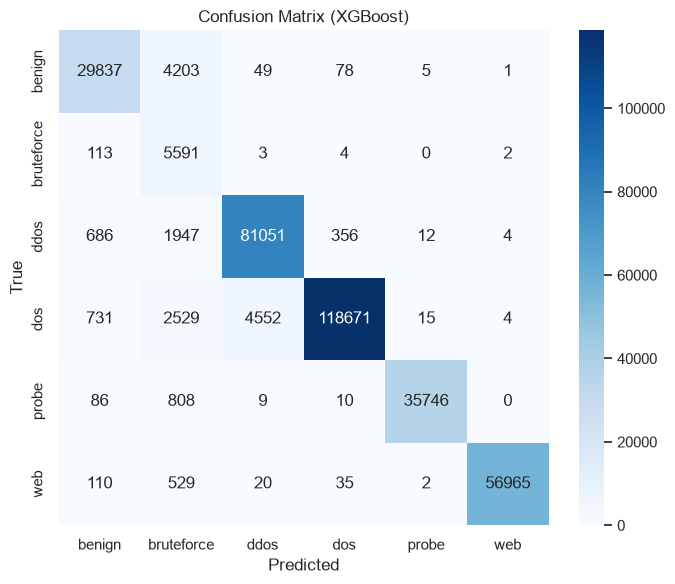

In [32]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix ({model_name})")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150)
plt.show()


In [33]:
# Commonly-confused class pairs, ranked by count
cm_off_diag = cm.astype(float).copy()
np.fill_diagonal(cm_off_diag, 0)

confused_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm_off_diag[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_off_diag[i, j])))
confused_pairs.sort(key=lambda x: -x[2])

print("Most commonly confused pairs (true -> predicted : count):")
for true_c, pred_c, count in confused_pairs[:10]:
    print(f"  {true_c:15s} -> {pred_c:15s} : {count}")


Most commonly confused pairs (true -> predicted : count):
  dos             -> ddos            : 4552
  benign          -> bruteforce      : 4203
  dos             -> bruteforce      : 2529
  ddos            -> bruteforce      : 1947
  probe           -> bruteforce      : 808
  dos             -> benign          : 731
  ddos            -> benign          : 686
  web             -> bruteforce      : 529
  ddos            -> dos             : 356
  bruteforce      -> benign          : 113


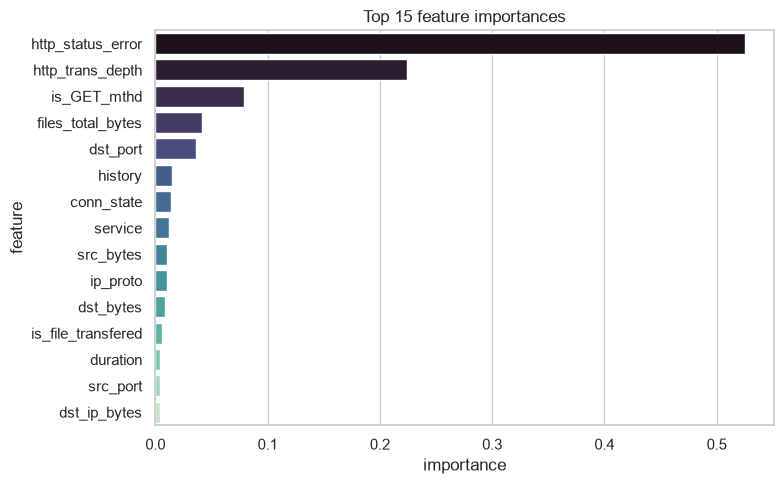

,feature,importance
18,http_status_error,0.524782
15,http_trans_depth,0.223858
17,is_GET_mthd,0.079113
16,files_total_bytes,0.041586
1,dst_port,0.036553
9,history,0.014607
7,conn_state,0.013978
3,service,0.011818
5,src_bytes,0.010609
14,ip_proto,0.010170


In [34]:
# Feature importance -- useful context for the report and a sanity check ahead of SHAP (Part 3)
if model_name == "XGBoost":
    importances = model.feature_importances_
else:
    importances = model.feature_importances_

imp_df = pd.DataFrame({"feature": feature_cols, "importance": importances}).sort_values(
    "importance", ascending=False
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=imp_df.head(15), x="importance", y="feature", ax=ax, palette="mako")
ax.set_title("Top 15 feature importances")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150)
plt.show()
imp_df.head(15)


## 7. Export per-test-event predictions

Each test event gets: predicted class, confidence, and top-k alternative predictions.
`true_label` is kept here **only** for our own offline evaluation later — it is explicitly
excluded when we build the CTI alert in Part 2, since the brief requires the LLM never see
the ground truth.


In [35]:
records = []
for row_idx, true_label, pred_label, proba in zip(idx_test, y_test, y_pred, y_proba):
    top_indices = np.argsort(proba)[::-1][:TOP_K_ALTERNATIVES]
    alternatives = [
        {"class": str(class_names[ti]), "confidence": round(float(proba[ti]), 4)}
        for ti in top_indices
    ]
    row = df.loc[row_idx]
    record = {
        "event_id": str(row.get("uid", row.get("event_id", f"row_{row_idx}"))),
        "timestamp": str(row.get("timestamp", "")),
        "true_label": str(class_names[true_label]),        # for OUR evaluation only -- not sent to the LLM
        "true_attack_type": str(row.get("attack_type", "")),  # finer-grained ground truth, also NOT sent to the LLM
        "predicted_class": str(class_names[pred_label]),
        "confidence": round(float(proba[pred_label]), 4),
        "alternative_predictions": alternatives,
        # raw feature snapshot (leakage cols excluded), used to populate
        # "relevant network observations" in Part 2
        "raw_features": {c: (row[c].item() if hasattr(row[c], "item") else row[c]) for c in feature_cols},
    }
    records.append(record)

print(f"Exported {len(records)} test-event records.")
print(json.dumps(records[0], indent=2, default=str))

with open(os.path.join(PROCESSED_DIR, "test_predictions.json"), "w") as f:
    json.dump(records, f, indent=2, default=str)


Exported 344764 test-event records.
{
  "event_id": "CamG7QmkphbjT5xn2",
  "timestamp": "",
  "true_label": "web",
  "true_attack_type": "http_flood",
  "predicted_class": "web",
  "confidence": 1.0,
  "alternative_predictions": [
    {
      "class": "web",
      "confidence": 1.0
    },
    {
      "class": "benign",
      "confidence": 0.0
    },
    {
      "class": "dos",
      "confidence": 0.0
    }
  ],
  "raw_features": {
    "src_port": 60368,
    "dst_port": 80,
    "proto": "tcp",
    "service": "http",
    "duration": 0.14495,
    "src_bytes": 142.0,
    "dst_bytes": 686.0,
    "conn_state": "SF",
    "missed_bytes": 0,
    "history": "ShADadfF",
    "src_pkts": 6,
    "src_ip_bytes": 462,
    "dst_pkts": 5,
    "dst_ip_bytes": 954,
    "ip_proto": 6,
    "http_trans_depth": 1,
    "files_total_bytes": 459.0,
    "is_GET_mthd": 1,
    "http_status_error": 1,
    "is_file_transfered": 1
  }
}


## 8. Save the model and encoders

Needed so Part 2 (and the Part 4 demo) can load the trained model without retraining.


In [36]:
import pickle

with open(os.path.join(MODEL_DIR, "threat_classifier.pkl"), "wb") as f:
    pickle.dump({
        "model": model,
        "model_name": model_name,
        "label_encoder": label_encoder,
        "feature_encoders": encoders,
        "feature_cols": feature_cols,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "class_names": list(class_names),
    }, f)

print("Saved model artifact to", os.path.join(MODEL_DIR, "threat_classifier.pkl"))


Saved model artifact to ../models\threat_classifier.pkl


---
### Next step
Part 2 (`02_cti_alert_generation.ipynb`) loads `data/processed/test_predictions.json` and
`models/threat_classifier.pkl`, builds structured CTI alerts (excluding `true_label`), and
sends them to a local LLM via Ollama for enrichment.
